# Trader Performance vs Market Sentiment Analysis

## Objective

This project explores the relationship between Bitcoin market sentiment and trader performance using:

1. Bitcoin Fear & Greed Index Dataset
2. Hyperliquid Historical Trader Data

The goal is to identify how market sentiment affects trader profitability, win rate, trading behavior, and risk.

# Data Loading

Import required libraries and load the datasets.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries added successfully")

Libraries added successfully


In [61]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

/tmp/ipykernel_2766/2628453973.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [62]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [63]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


# Data Understanding

Examine dataset dimensions, column types, and missing values to understand data quality before analysis.

In [64]:
print("Sentiment Shape", sentiment.shape)
print("Trades Shape", trades.shape)

Sentiment Shape (2644, 4)
Trades Shape (65149, 16)


In [65]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [66]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65149 entries, 0 to 65148
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           65149 non-null  object 
 1   Coin              65149 non-null  object 
 2   Execution Price   65149 non-null  float64
 3   Size Tokens       65149 non-null  float64
 4   Size USD          65149 non-null  float64
 5   Side              65149 non-null  object 
 6   Timestamp IST     65149 non-null  object 
 7   Start Position    65149 non-null  float64
 8   Direction         65149 non-null  object 
 9   Closed PnL        65149 non-null  float64
 10  Transaction Hash  65149 non-null  object 
 11  Order ID          65148 non-null  float64
 12  Crossed           65148 non-null  object 
 13  Fee               65148 non-null  float64
 14  Trade ID          65148 non-null  float64
 15  Timestamp         65148 non-null  float64
dtypes: float64(9), object(7)
memory usage: 8

In [67]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [68]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


# Data Cleaning and Preparation

Convert date columns into datetime format and create a common date field for merging the datasets.

In [69]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [70]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [71]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [72]:
sentiment['trade_date'] = sentiment['date'].dt.date

In [73]:
print('trade_date' in trades.columns)
print('trade_date' in sentiment.columns)

False
True


In [74]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['trade_date'] = trades['Timestamp IST'].dt.date

In [75]:
print('trade_date' in trades.columns)

True


In [76]:
merged = pd.merge(trades, sentiment[['trade_date', 'classification', 'value']],on='trade_date', how='left')

In [77]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [78]:
merged[['trade_date', 'classification']].head()

,trade_date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [79]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst = True)

In [80]:
trades['trade_date'] = trades['Timestamp IST'].dt.date

In [81]:
trades[['Timestamp IST', 'trade_date']].head()

,Timestamp IST,trade_date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [82]:
sentiment['date'].dtype

dtype('<M8[ns]')

In [83]:
sentiment['trade_date'] = pd.to_datetime(sentiment['date']).dt.date

# Data Integration

Merge trading data with market sentiment data using trade dates.

In [84]:
merged = pd.merge(trades, sentiment[['trade_date', 'classification', 'value']], on='trade_date', how='left')

In [85]:
merged[['trade_date','classification']].head(10)

,trade_date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed
5,2024-12-02,Extreme Greed
6,2024-12-02,Extreme Greed
7,2024-12-02,Extreme Greed
8,2024-12-02,Extreme Greed
9,2024-12-02,Extreme Greed


# Sentiment Distribution Analysis

Analyze how trading activity is distributed across different market sentiment conditions.

In [86]:
merged['classification'].value_counts()

,count
classification,
Greed,19567
Fear,17630
Neutral,14567
Extreme Greed,10704
Extreme Fear,2675


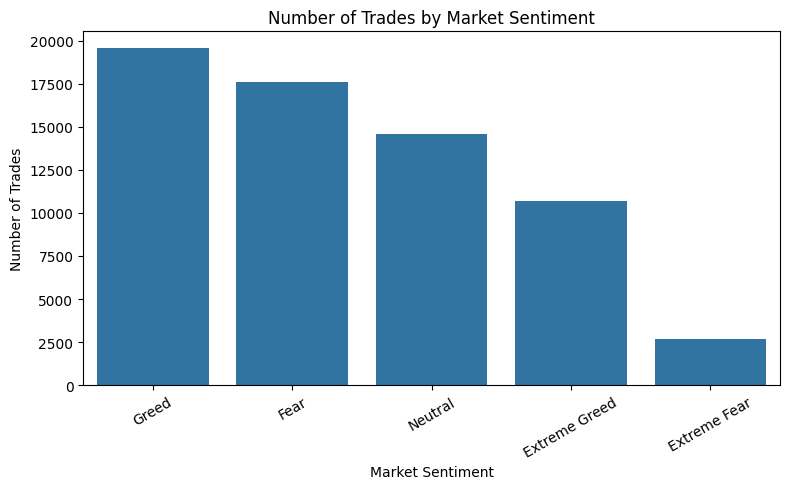

In [87]:
plt.figure(figsize=(8,5))

sns.countplot(data=merged,x='classification',order=merged['classification'].value_counts().index)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observation

Fear periods recorded the highest number of trades, while Extreme Fear periods had the lowest trading activity. This suggests that traders remain highly active during uncertain market conditions.

# Profitability Analysis

Compare trader profitability across different market sentiment conditions.

In [88]:
merged.groupby('classification')['Closed PnL'].agg(['count','mean','median','sum']).sort_values('mean',ascending=False)

,count,mean,median,sum
classification,,,,
Extreme Greed,10704,155.421657,0.858285,1.663633e+06
Extreme Fear,2675,136.513030,0.000000,3.651724e+05
Fear,17630,105.645009,0.000000,1.862522e+06
Greed,19567,79.989840,0.000000,1.565161e+06
Neutral,14567,77.708515,0.000000,1.131980e+06


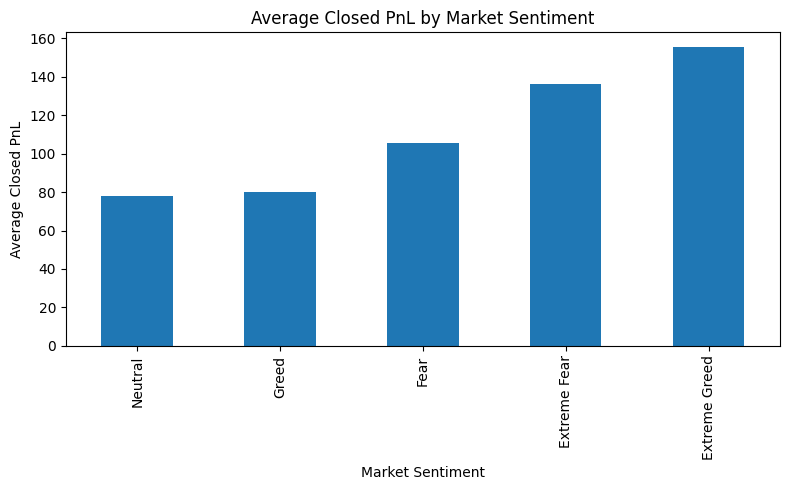

In [89]:
plt.figure(figsize=(8,5))

pnl_mean = (merged.groupby('classification')['Closed PnL'].mean().sort_values())

pnl_mean.plot(kind='bar')

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.tight_layout()

plt.show()

### Observation

Extreme Greed periods generated the highest average profit per trade, followed by Fear periods. Neutral and Extreme Fear conditions produced lower average profits.

# Win Rate Analysis

Evaluate how frequently traders generate profitable trades under different market sentiments.

In [90]:
merged['win']=merged['Closed PnL'] > 0

In [91]:
win_rate=merged.groupby('classification')['win'].mean()*100
print(win_rate)

classification
Extreme Fear     38.392523
Extreme Greed    53.886398
Fear             42.977879
Greed            40.312772
Neutral          45.156861
Name: win, dtype: float64


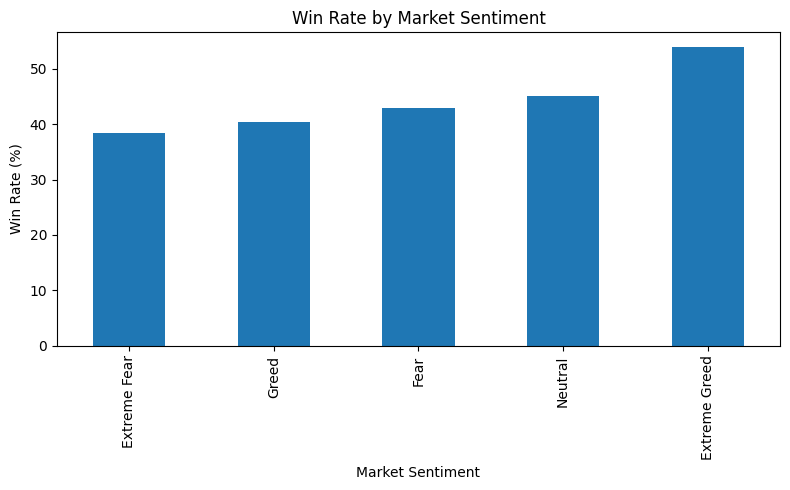

In [92]:
plt.figure(figsize=(8,5))

win_rate.sort_values().plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.tight_layout()
plt.show()

### Observation

The highest win rate was observed during Extreme Greed periods, while Extreme Fear periods showed the lowest win rate.

# Buy vs Sell Performance Analysis

Investigate whether BUY and SELL trades perform differently across sentiment conditions.

In [93]:
merged.groupby(['classification','Side'])['Closed PnL'].mean()

classification  Side
Extreme Fear    BUY     207.684830
                SELL     55.983982
Extreme Greed   BUY      30.047354
                SELL    254.463164
Fear            BUY     168.950612
                SELL     43.124482
Greed           BUY      60.453090
                SELL     97.143327
Neutral         BUY      80.266777
                SELL     74.865096
Name: Closed PnL, dtype: float64

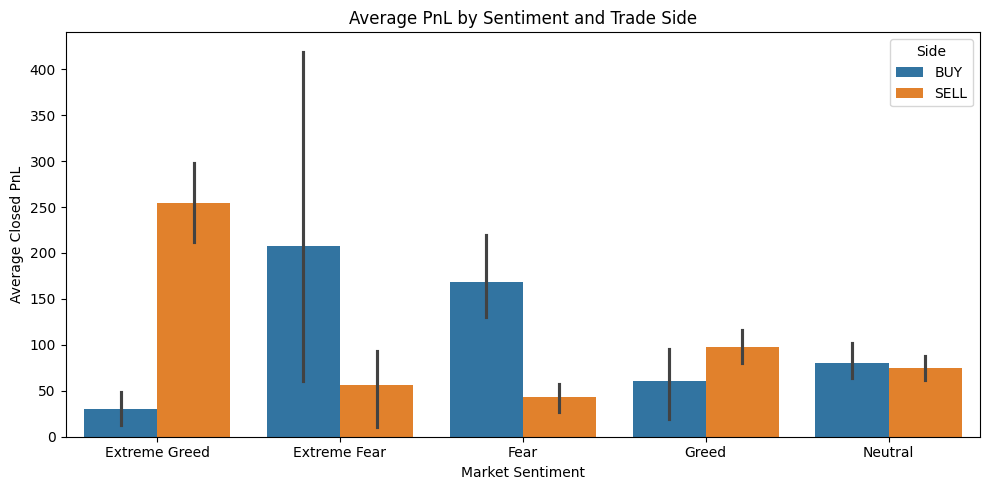

In [94]:
plt.figure(figsize=(10,5))

sns.barplot(data=merged,x='classification',y='Closed PnL',hue='Side')

plt.title("Average PnL by Sentiment and Trade Side")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.tight_layout()
plt.show()

### Observation

BUY trades performed better during Fear periods, whereas SELL trades generated significantly higher profits during Greed and Extreme Greed periods.

In [95]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'trade_date', 'classification', 'value', 'win'],
      dtype='object')

# Trade Size Analysis

Analyze whether traders deploy different amounts of capital under different market sentiment conditions.

In [96]:
merged.groupby('classification')['Size USD'].agg(['count','mean','median','max']).sort_values('mean',ascending=False)

,count,mean,median,max
classification,,,,
Fear,17630,16285.248687,1000.570,3921430.72
Greed,19567,11526.262066,1118.500,2227114.71
Neutral,14567,8567.542729,769.180,3641180.84
Extreme Greed,10704,7353.763388,1068.105,665771.71
Extreme Fear,2675,7016.695966,914.740,685200.00


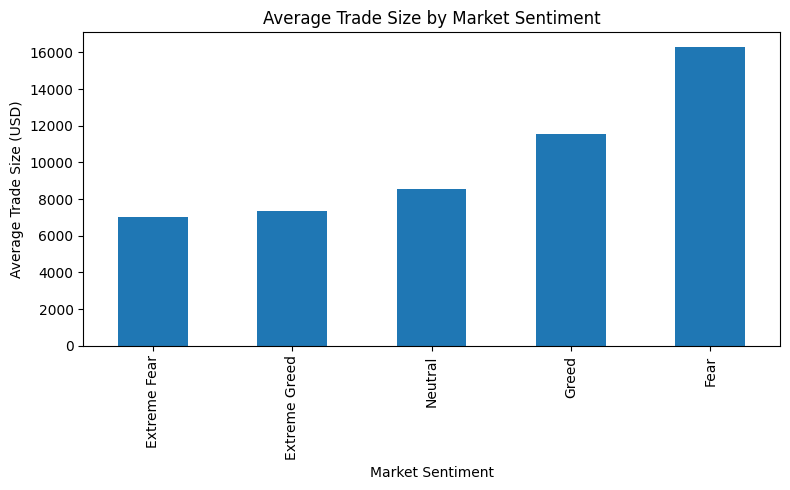

In [97]:
plt.figure(figsize=(8,5))

merged.groupby('classification')['Size USD'].mean().sort_values().plot(kind='bar')

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.tight_layout()
plt.show()

### Observation

Average trade sizes varied across sentiment categories, indicating that trader risk appetite changes with market sentiment.

# Fee Analysis

Examine trading fees across sentiment conditions as a proxy for trading activity and position size.

In [98]:
merged.groupby('classification')['Fee'].agg(['mean','median','sum']).sort_values('mean',ascending=False)

,mean,median,sum
classification,,,
Fear,2.888550,0.152395,50925.142690
Greed,2.575831,0.175791,50401.277882
Neutral,1.870578,0.121893,27246.845264
Extreme Fear,1.812223,0.209243,4847.697782
Extreme Greed,1.753530,0.110523,18769.780508


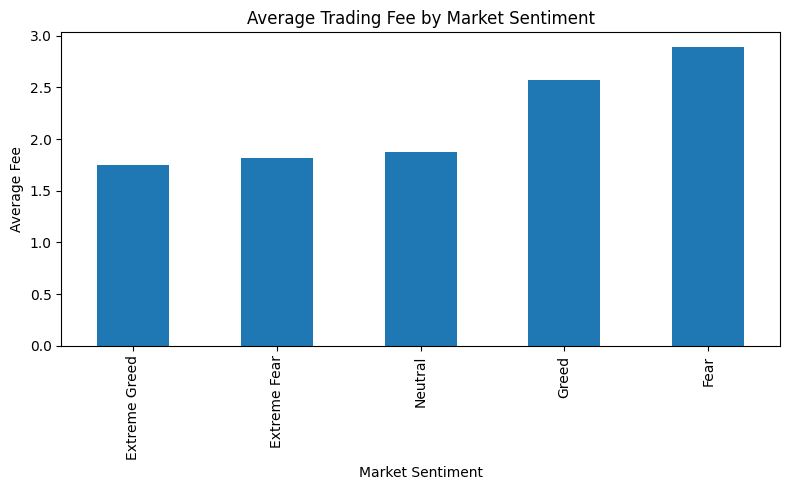

In [99]:
plt.figure(figsize=(8,5))

merged.groupby('classification')['Fee'].mean().sort_values().plot(kind='bar')

plt.title("Average Trading Fee by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Fee")

plt.tight_layout()
plt.show()

### Observation

Fee patterns suggest that trader activity and position sizes differ across market sentiment conditions.

# Coin Performance Analysis

Identify which cryptocurrencies generated the highest profits for traders.

In [100]:
top_coins = merged.groupby('Coin')['Closed PnL'].agg(['count','mean','sum']).sort_values('sum',ascending=False).head(10)
top_coins

,count,mean,sum
Coin,,,
@107,8110,235.145930,1.907033e+06
SOL,3021,392.050161,1.184384e+06
BTC,16820,49.756930,8.369116e+05
ETH,7002,117.694952,8.241001e+05
HYPE,12751,57.820008,7.372629e+05
ZRO,309,600.134568,1.854416e+05
DOGE,340,429.600329,1.460641e+05
BERA,553,154.506022,8.544183e+04
USUAL,423,155.223843,6.565969e+04


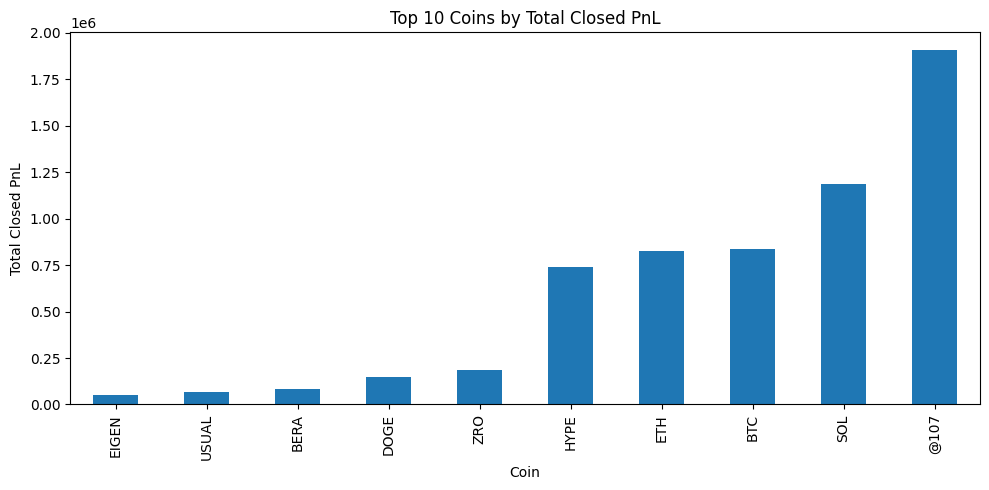

In [101]:
plt.figure(figsize=(10,5))

top_coins['sum'].sort_values().plot(kind='bar')

plt.title("Top 10 Coins by Total Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")

plt.tight_layout()
plt.show()

### Observation

A small number of coins contributed a large share of total profitability, indicating concentrated trading opportunities.

# Top Trader Analysis

Identify the most profitable trader accounts in the dataset.

In [102]:
top_traders = (merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False))
top_traders.head(10)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a,1.087312e+05


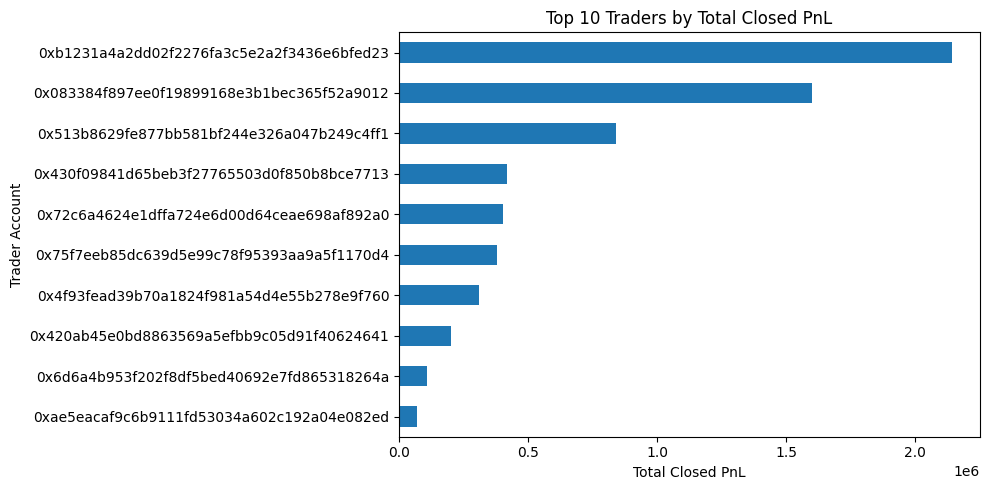

In [103]:
plt.figure(figsize=(10,5))

top_traders.head(10).sort_values().plot(kind='barh')

plt.title("Top 10 Traders by Total Closed PnL")
plt.xlabel("Total Closed PnL")
plt.ylabel("Trader Account")

plt.tight_layout()
plt.show()

### Observation

Profitability is highly concentrated among a small number of trader accounts, suggesting differences in trading skill, strategy, or risk-taking behavior.

# Risk Analysis

Measure trading risk using the standard deviation of Closed PnL across sentiment categories.

In [104]:
risk_analysis = (merged.groupby('classification')['Closed PnL'].std().sort_values(ascending=False))
risk_analysis

,Closed PnL
classification,
Extreme Fear,2568.490344
Fear,1605.269359
Greed,1402.875169
Extreme Greed,1385.692472
Neutral,748.922073


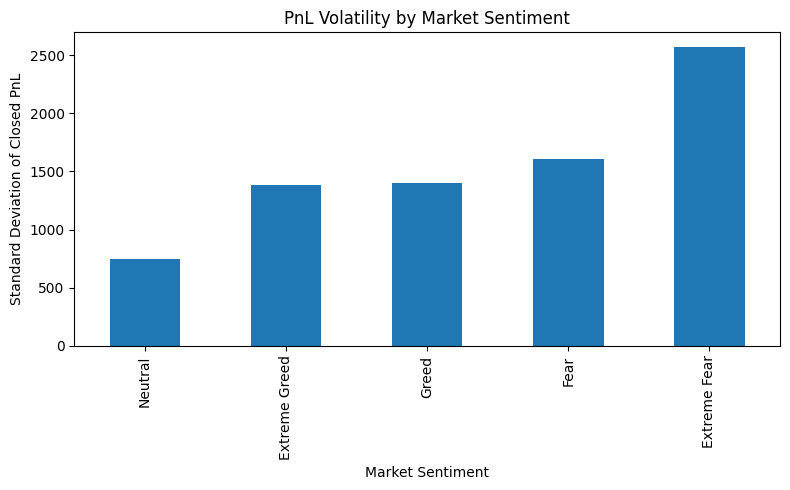

In [105]:
plt.figure(figsize=(8,5))

risk_analysis.sort_values().plot(kind='bar')

plt.title("PnL Volatility by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Standard Deviation of Closed PnL")

plt.tight_layout()
plt.show()

### Observation

Profitability and risk do not always move together. Some sentiment conditions offer higher profits but also exhibit greater volatility.

# Conclusion

## Key Findings

1. Extreme Greed periods generated the highest average profit per trade.
2. Extreme Greed periods also produced the highest trader win rate.
3. Fear periods recorded the highest trading activity.
4. BUY trades performed better during Fear periods, while SELL trades outperformed during Greed and Extreme Greed periods.
5. Trading behavior, position sizes, and fees varied across sentiment conditions.
6. Risk levels differed across market sentiment states.

## Recommendation

Market sentiment appears to influence trader performance and behavior. Incorporating sentiment indicators into trading strategies may help traders improve decision-making while balancing profitability and risk.